In [1]:
%load_ext autoreload
%autoreload 2

import rootutils
rootutils.setup_root('.', dotenv=True, pythonpath=True, cwd=True)

PosixPath('/home/milton/workspace/ocdm')

In [6]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from pathlib import Path

import numpy as np
import torch
from torchvision.utils import make_grid

from src.model.vae import BetaVAE, WassersteinMMDAE
from src.model.slot import SlotAutoencoder, FigureGroundAutoencoder
from src.dataset.dsprites import DSprites
from src.dataset.shapes3d import Shapes3D
from src.dataset.pentominos import Pentominos
from src.dataset.utils import build_filter
from src.analysis.viz import strip

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [7]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Dummy function to simulate loading images

SPLIT_FONT_SIZE=24
MODEL_NAME_FONT_SIZE = 20
FACTOR_NAME_FONT_SIZE = 20
FACTOR_VALUE_FONT_SIZE = 18

def plot_examples(images):
    tl_images = images[:1, :2]
    tr_images = images[:1, 2:]

    bl_images = images[1:, :2]
    br_images = images[1:, 2:]

    images = [tl_images, tr_images, br_images, bl_images]
    
    fig = plt.figure(figsize=(12, 8))
    
    # --- Top-level grid with 2x2 panels ---
    outer_gs = GridSpec(
        2, 2, figure=fig,
        width_ratios=[2, 4],
        height_ratios=[1, 3],
        wspace=0.07, hspace=0.1      # spacing *between* panels
    )
    
    # Panel definitions (rows, cols)
    panels = [
        (1, 2),  # top-left
        (1, 4),  # top-right
        (3, 4),  # bottom-right
        (3, 2),  # bottom-left
    ]
    
    # Mapping outer grid cells in clockwise order
    outer_positions = [
        (0, 0),  # TL
        (0, 1),  # TR
        (1, 1),  # BR
        (1, 0),  # BL
    ]

    light_blue = (0.0, 0.5, 1.0)
    panel_colors = [light_blue, 'orange', 'orange', light_blue]

    axes = []
    for (rows, cols), pos, panel_imgs, pc in zip(panels, outer_positions, images, panel_colors):
        # Create the panel axis container
        ax_panel = fig.add_subplot(outer_gs[pos])
        strip(ax_panel)
        ax_panel.set_frame_on(False)   
    
        # Create a sub-grid inside this panel
        inner_gs = outer_gs[pos].subgridspec(
            rows, cols,
            wspace=0.05, hspace=0.06            # spacing *between images*
        )
    
        for r in range(rows):
            for c in range(cols):
                ax = fig.add_subplot(inner_gs[r, c])
                ax.imshow(panel_imgs[r, c], cmap="gray" if panel_imgs.shape[-1] == 1 else None)
                strip(ax)
                ax.set_aspect("auto")

        # after creating ax_panel:
        bbox = ax_panel.get_position()
        
        pad = 0.0075      # how much larger the frame is around the panel
        linewidth = 4     # frame thickness
        radius = 0.01     # corner rounding (0.02–0.05 works well)
        
        rounded = patches.FancyBboxPatch(
            (bbox.x0 - pad, bbox.y0 - 1.25 * pad),
            bbox.width + 2 * pad,
            bbox.height + (2.5) * pad,
            boxstyle=f"round,pad=0,rounding_size={radius}",
            linewidth=linewidth,
            edgecolor=pc,
            facecolor="none",
            transform=fig.transFigure,
            zorder=10,
        )
        
        fig.patches.append(rounded)
        axes.append(ax_panel)

    axes[0].text(0.5, 1.18, "Train", fontsize=SPLIT_FONT_SIZE, rotation=0, ha='center', va='center')
    axes[1].text(0.5, 1.18, "Test", fontsize=SPLIT_FONT_SIZE, rotation=0, ha='center', va='center')

    fig.canvas.draw()
    
    return fig, axes

# Figure 1

## Position generalisation in dSprites

In [8]:
_filter = build_filter(DSprites, "( shape == 3 ) & ( posY > 0.51 ) & ( posY < 0.52 ) & ( scale == 0.8 ) & ( orientation > 1.4 ) & ( orientation < 1.5 )")
dsprite_plot = DSprites("data/datasets/dsprites/dsprites_train.hdf5", data_filter=_filter)

In [14]:
vae_runs = [
    "data/logs/figure1/combgen_dsprites_heart_position/vae/2026-03-31_19-37/epoch=57-step=495000.ckpt"
]

wae_runs = [
    "data/logs/figure1/combgen_dsprites_heart_position/wae/2026-03-31_13-59/epoch=54-step=470000.ckpt"
]

sa_runs = [
    # "data/logs/figure1/combgen_dsprites_heart_position/sa/2026-03-19_06-06/epoch=514-step=494400.ckpt",
    "data/logs/figure1/combgen_dsprites_heart_position/sa/2026-03-31_16-59/epoch=57-step=495000.ckpt"
]


sa1 = FigureGroundAutoencoder.load_from_checkpoint(sa_runs[0]).cpu()
vae = BetaVAE.load_from_checkpoint(vae_runs[0]).cpu()
wae = WassersteinMMDAE.load_from_checkpoint(wae_runs[0]).cpu()

print(vae.latent.size, wae.latent.size, sa1.fig_rep.size)

64 64 64


In [15]:
examples = torch.stack([dsprite_plot[i][0] for i in range(0, len(dsprite_plot), 3)])[:-1]

vae_recons = vae(examples)[0].sigmoid()
wae_recons = wae(examples)[0].clip(0, 1)
sa1_recons = sa1(examples)[0].clip(0, 1)

to_retain_idx = np.asarray([0, 2, 6, 7, 8, 9])

if to_retain_idx is not None:
    examples = examples[to_retain_idx]
    vae_recons = vae_recons[to_retain_idx]
    wae_recons = wae_recons[to_retain_idx]
    sa1_recons = sa1_recons[to_retain_idx]

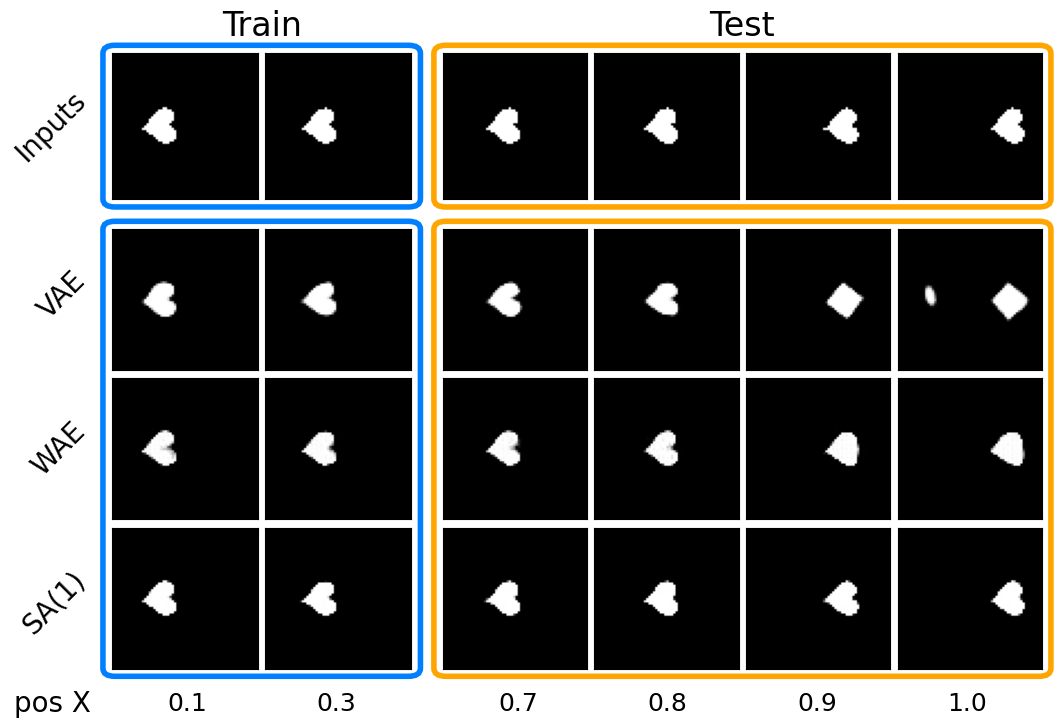

In [16]:
images = torch.stack([examples, vae_recons, wae_recons, sa1_recons], dim=0).permute(0, 1, 3, 4, 2).numpy()
images = np.flip(images[:, ::-1], axis=-2)
fig, [ax_tl, ax_tr, ax_br, ax_bl] = plot_examples(images)

ax_tl.text(-0.07, 0.5, "Inputs", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.85, "VAE", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.5, "WAE", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.15, "SA(1)", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')

#-------------------------------------------------------------
# Placing values of the x position
#-------------------------------------------------------------
import matplotlib.patches as patches

# values = DSprites.unique_values['posX'][::3][:-1]
texts = []
values = np.linspace(0.1, 1, 10, endpoint=True)
if to_retain_idx is not None:
    values = values[to_retain_idx]

y = -0.08
ax_bl.text(-0.2, y, "pos X", fontsize=FACTOR_NAME_FONT_SIZE, rotation=0.0, ha='center', va='center')
for i, v in enumerate(values[:2]):
    texts.append(ax_bl.text(0.25 + i * 0.5, y, f"{v.item():1.1f}", fontsize=FACTOR_VALUE_FONT_SIZE, ha='center', va='center'))

for i, v in enumerate(values[2:]):
    texts.append(ax_br.text(0.125 + i * 0.25, y, f"{v.item():1.1f}", fontsize=FACTOR_VALUE_FONT_SIZE, ha='center', va='center'))

# # --- 2. Force a draw so text bounding boxes exist ---
# fig.canvas.draw()
#
# bboxes = [t.get_window_extent() for t in texts]
# bbox = bboxes[0]
# bbox = bbox.union(bboxes)
#
# inv = ax_bl.transData.inverted()
# bbox_data = inv.transform([[bbox.x0, bbox.y0], [bbox.x1, bbox.y1]])
#
# # ---- 4. Convert bbox from DISPLAY -> DATA coordinates ----
# (x0, y0), (x1, y1) = ax_bl.transData.inverted().transform(
#     [(bbox.x0, bbox.y0), (bbox.x1, bbox.y1)]
# )
#
#
# # --- 4. Add a rectangle patch around the union bounding box ---
# pad_x, pad_y = 0.07, 0.07
# rect = patches.Rectangle(
#     (x0 - pad_x - 0.15, y0 + pad_y - 0.01),
#     x1 - x0 + pad_x * 2 + 0.3,
#     y1 - y0 - pad_y * 1.7,
#     linewidth=2,
#     edgecolor='black',
#     facecolor='none',      # or 'white' + alpha
#     zorder=-1              # behind text
# )
#
# rect.set_clip_on(False)
# ax_bl.add_patch(rect)
fig.savefig("plots/dsprites_position_generalisation_v3.svg", bbox_inches='tight', pad_inches=0)

## Object hue generalisation in 3DShapes

In [34]:
_filter = build_filter(
    Shapes3D,
    # "( shape == 3 ) & ( floor_hue == 0.2 ) & ( wall_hue == 0.8) * ( orientation == 0.0 ) & ( scale > 1.035 ) & ( scale < 1.036 )"
    "( shape == 3 ) & ( floor_hue == 0.2 ) & ( wall_hue == 0.8) * ( orientation == -30 ) & ( scale > 1.24 ) & ( scale < 1.26 )"
)

# ( wall_hue == 0.8 ) & ( scale > 1.035 ) & ( scale < 1.036 ) & 
shapes3d_plot = Shapes3D("data/datasets/shapes3d/3dshapes.h5", data_filter=_filter)

In [56]:
vae_runs = [
    "data/logs/figure1/combgen_shapes3d_shape_hue/vae/2026-04-01_10-03/epoch=16-step=100000.ckpt"
]

wae_runs = [
    "data/logs/figure1/combgen_shapes3d_shape_hue/wae/2026-04-01_10-26/epoch=75-step=460000.ckpt"
]

sa_runs = [
    # "data/logs/figure1/combgen_shapes3d_shape_hue/sa/2026-04-d_05-39/epoch=78-step=475000.ckpt"
    # "data/logs/figure1/combgen_shapes3d_shape_hue/sa/2026-04-d_05_39/epoch=78-step=475000.ckpt"
    "data/results/old/figure1/combgen_shapes3d_shape_hue_sa_on:2025-11-19_18-02/epoch=147-step=99900.ckpt"
]

sa1 = SlotAutoencoder.load_from_checkpoint(sa_runs[0]).cpu()
vae = BetaVAE.load_from_checkpoint(vae_runs[0]).cpu()
wae = WassersteinMMDAE.load_from_checkpoint(wae_runs[0]).cpu()

print(vae.latent.size, wae.latent.size, sa1.slot_attention.slot_size)

64 64 64


In [52]:

examples = torch.stack([shapes3d_plot[i][0] for i in range(len(shapes3d_plot))])

vae_recons = vae(examples)[0].sigmoid()
wae_recons = wae(examples)[0].clip(0, 1)
sa1_recons = sa1(examples)[0].clip(0, 1)

to_retain_idx = np.asarray([0, 2, 6, 7, 8, 9])
# to_retain_idx = None

if to_retain_idx is not None:
    examples = examples[to_retain_idx]
    vae_recons = vae_recons[to_retain_idx]
    wae_recons = wae_recons[to_retain_idx]
    sa1_recons = sa1_recons[to_retain_idx]

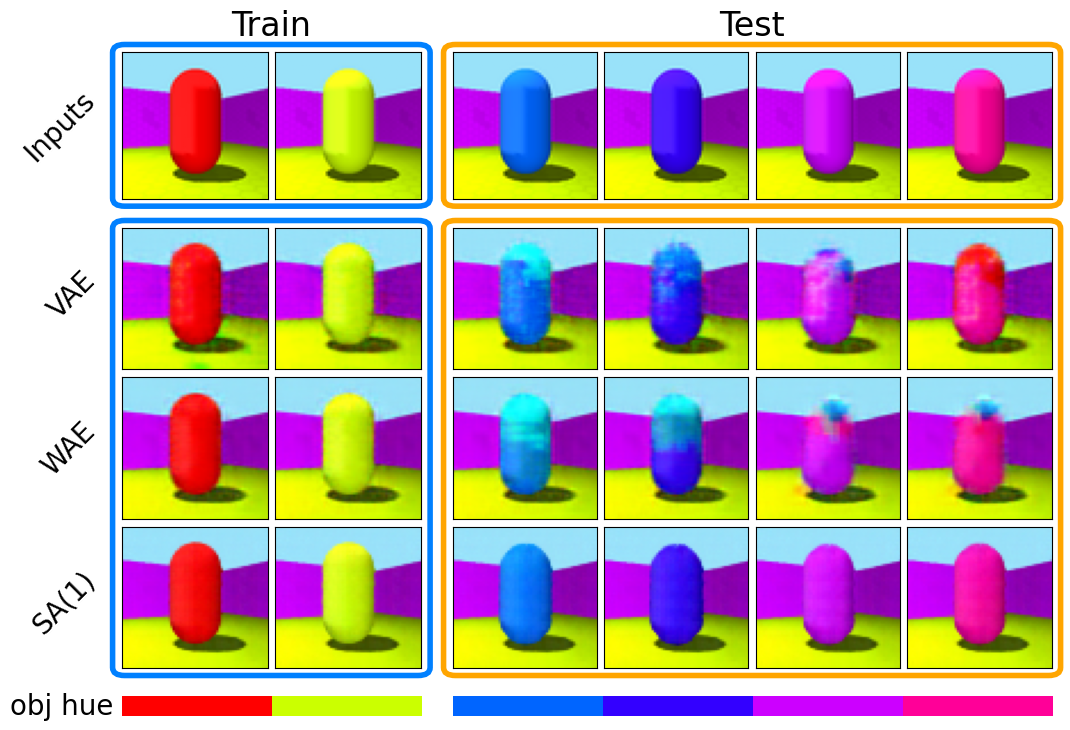

In [53]:
images = torch.stack([examples, vae_recons, wae_recons, sa1_recons], dim=0).permute(0, 1, 3, 4, 2).numpy()
fig, [ax_tl, ax_tr, ax_br, ax_bl] = plot_examples(images)

ax_tl.text(-0.07, 0.5, "Inputs", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.85, "VAE", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.5, "WAE", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.15, "SA(1)", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')

# ----------------------------------------
# Placing the factor values
# ----------------------------------------

from matplotlib.transforms import Bbox
from matplotlib.colors import hsv_to_rgb

bbox1 = ax_bl.get_position()
bbox2 = ax_br.get_position()


h = 0.025  # height of the hue bar
y_offset = 0.06  # distance below the main axis

hue_ax1 = fig.add_axes([
    bbox1.x0,                 # left aligned with main axis
    bbox1.y0 - y_offset,      # placed beneath
    bbox1.width,              # same width
    h                         # small height
])

hue_ax2 = fig.add_axes([
    bbox2.x0,                 # left aligned with main axis
    bbox2.y0 - y_offset,      # placed beneath
    bbox2.width,              # same width
    h                         # small height
])

hue_ax1.text(-0.9, 0, "obj hue", fontsize=FACTOR_NAME_FONT_SIZE, rotation=0.0, ha='center', va='center')

h = (np.linspace(0, 1, 10, endpoint=False)) % 1.0          # hue values
if to_retain_idx is not None:
    h = h[to_retain_idx]

s = np.ones_like(h)                 # saturation = 1
v = np.ones_like(h)                 # value = 1

hsv = np.stack([h, s, v], axis=1)   # Nx3
rgb = hsv_to_rgb(hsv)[None, :, :]   # shape: (1, N, 3)

hue_ax1.imshow(rgb[:, :2], aspect="auto")
hue_ax2.imshow(rgb[:, 2:], aspect="auto")
hue_ax1.set_axis_off()   # remove ticks/borders
hue_ax2.set_axis_off()   # remove ticks/borders


fig.savefig("plots/shapes3d_hue_generalisation_v3.svg", bbox_inches='tight', pad_inches=0)

## Rotation generalisation in dSprites

In [66]:
_filter = build_filter(DSprites, "( shape == 3 ) & ( posY > 0.51 ) & ( posY < 0.52 ) & ( posX > 0.51 ) & ( posX < 0.52 ) & ( scale == 0.8 )")
dsprite_plot = DSprites("data/datasets/dsprites/dsprites_train.hdf5", data_filter=_filter)

In [63]:
vae_runs = [
    "data/logs/combgen_dsprites_heart_rotation/vae/2026-03-31_11-51/epoch=2-step=20000.ckpt",
]

wae_runs = [
    "data/logs/combgen_dsprites_heart_rotation/wae/2026-03-31_13-58/epoch=52-step=455000.ckpt",
]

sa_runs = [
    "data/logs/combgen_dsprites_heart_rotation/sa/2026-04-01_11-44/epoch=57-step=495000.ckpt",
]

sa1 = FigureGroundAutoencoder.load_from_checkpoint(sa_runs[0]).cpu()
vae = BetaVAE.load_from_checkpoint(vae_runs[0]).cpu()
wae = WassersteinMMDAE.load_from_checkpoint(wae_runs[0]).cpu()

In [67]:
examples = torch.stack([dsprite_plot[i][0] for i in range(0, len(dsprite_plot), 3)])[:-1]

vae_recons = vae(examples)[0].sigmoid()
wae_recons = wae(examples)[0].clip(0, 1)
sa1_recons = sa1(examples)[0].clip(0, 1)

to_retain_idx = np.asarray([11, 8, 6, 4, 2, 1])
# to_retain_idx = np.arange(6)
# to_retain_idx = None

if to_retain_idx is not None:
    examples = examples[to_retain_idx]
    vae_recons = vae_recons[to_retain_idx]
    wae_recons = wae_recons[to_retain_idx]
    sa1_recons = sa1_recons[to_retain_idx]

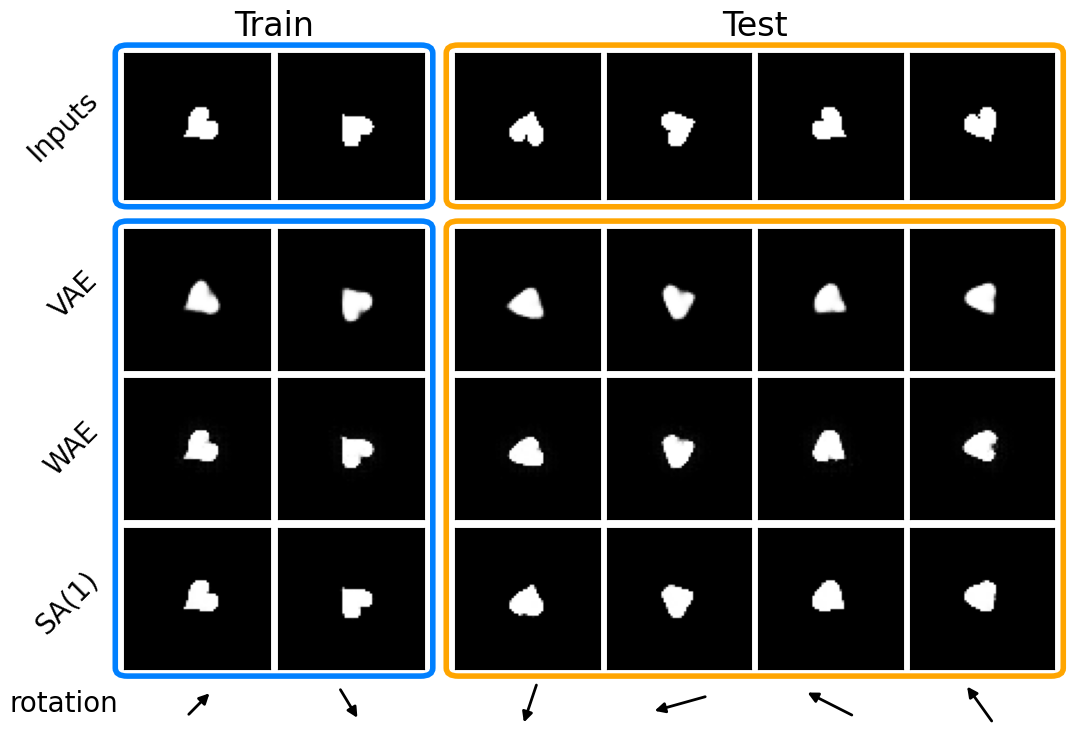

In [69]:
images = torch.stack([examples, vae_recons, wae_recons, sa1_recons], dim=0).permute(0, 1, 3, 4, 2).numpy()
fig, [ax_tl, ax_tr, ax_br, ax_bl] = plot_examples(images)

ax_tl.text(-0.07, 0.5, "Inputs", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.85, "VAE", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.5, "WAE", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.15, "SA(1)", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')

#-------------------------------------------------------------
# Plotting arrows indicating the rotation of the shapes
#-------------------------------------------------------------

import matplotlib.patches as FancyArrowPatch

y = -0.08
ax_bl.text(-0.2, y, "rotation", fontsize=FACTOR_NAME_FONT_SIZE, rotation=0.0, ha='center', va='center')

n_arrows = 13                  # number of arrows to draw
arrow_length = 0.1            # data units
arrow_width  = 0.008

def draw_arrows(angles, ax):
    x_min, x_max = ax.get_xlim()
    xs = np.linspace(x_min, x_max, len(angles), endpoint=False) + 1 / (2 * len(angles))
    y_min, y_max = ax.get_ylim()
    for x, angle in zip(xs, angles):
        # Arrow is drawn from (x, y_offset) to (x + dx, y_offset)
        dx = arrow_length * np.cos(angle)
        dy = arrow_length * np.sin(angle)
    
        arrow = FancyArrowPatch.FancyArrowPatch(
            # posA=(x - dx/2, y_offset - dy/2),   # center the arrow at x
            # posB=(x + dx/2, y_offset + dy/2),
            posA=(x - dx/2, - dy/2 + y),   # center the arrow at x
            posB=(x + dx/2, + dy/2 + y),
            arrowstyle='-|>', 
            mutation_scale=15,
            linewidth=2,
            color='black',
            zorder=10,
        )
    
        arrow.set_clip_on(False)
    
        ax.add_patch(arrow)

angles = (dsprite_plot.unique_values['orientation'][:-1:3] + np.pi / 2) % (2 * np.pi)

if to_retain_idx is not None:
    angles = angles[to_retain_idx]

draw_arrows(angles[:2], ax_bl)
draw_arrows(angles[2:], ax_br)

# Expand view so the arrows are visible
# ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1])

fig.savefig("plots/dsprites_rotation_generalisation_v3.svg", bbox_inches='tight', pad_inches=0)

# Figure 2

## Rotation generalisation with Pentominos

In [81]:
# _filter = build_filter(Pentominos, "( np.isin( shape ,  [1, 3, 5, 8] ) ) & ( pos_y > 0.52 ) & ( pos_y < 0.53 ) & ( pos_x > 0.52 ) & ( pos_x < 0.53 ) & ( scale == 2.25 )")
_filter = build_filter(Pentominos, "( shape == 6 ) & ( pos_y > 0.52 ) & ( pos_y < 0.53 ) & ( pos_x > 0.52 ) & ( pos_x < 0.53 ) & ( scale == 1.5 )")
pentominos_plot = Pentominos("data/datasets/pentominos", data_filter=_filter)

# Pentominos.unique_values

In [82]:
vae_runs = [
    "data/logs/figure2/combgen_pentominos_rotation/vae/2026-03-31_19-34/epoch=37-step=485000.ckpt"  # Gen for U
]

wae_runs = [
    "data/logs/figure2/combgen_pentominos_rotation/wae/2026-03-31_12-09/epoch=36-step=470000.ckpt" # Gen for U
]

sa_runs = [
    "data/logs/figure2/combgen_pentominos_rotation/sa/2026-03-31_15-25/epoch=36-step=470000.ckpt" # Gen for U
]

sa1 = FigureGroundAutoencoder.load_from_checkpoint(sa_runs[0]).cpu()
vae = BetaVAE.load_from_checkpoint(vae_runs[0]).cpu()
wae = WassersteinMMDAE.load_from_checkpoint(wae_runs[0]).cpu()

In [83]:
examples = torch.stack([pentominos_plot[i][0] for i in range(0, len(pentominos_plot), 3)])[:-1]

vae_recons = vae(examples)[0].sigmoid()
wae_recons = wae(examples)[0].clip(0, 1)
sa1_recons = sa1(examples)[0].clip(0, 1)

to_retain_idx = np.asarray([1, 4, 7, 8, 9, 10])
# to_retain_idx = np.arange(6)
# to_retain_idx = None

if to_retain_idx is not None:
    examples = examples[to_retain_idx]
    vae_recons = vae_recons[to_retain_idx]
    wae_recons = wae_recons[to_retain_idx]
    sa1_recons = sa1_recons[to_retain_idx]

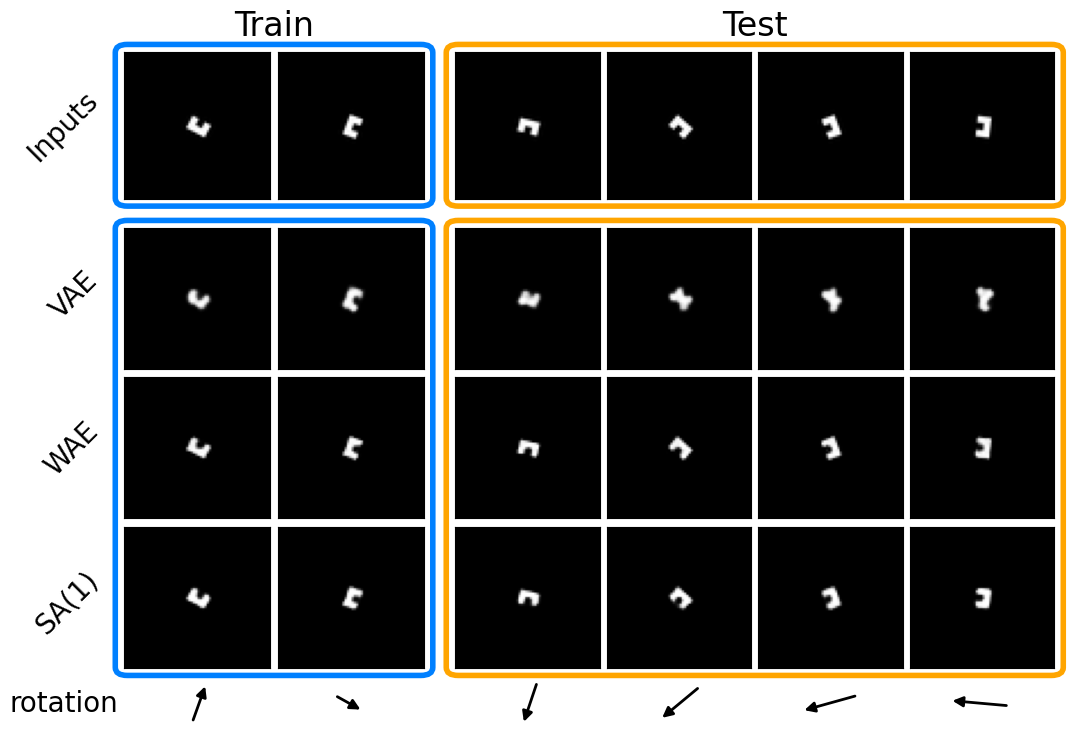

In [84]:
images = torch.stack([examples, vae_recons, wae_recons, sa1_recons], dim=0).permute(0, 1, 3, 4, 2).numpy()
fig, [ax_tl, ax_tr, ax_br, ax_bl] = plot_examples(images)

ax_tl.text(-0.07, 0.5, "Inputs", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.85, "VAE", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.5, "WAE", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')
ax_bl.text(-0.07, 0.15, "SA(1)", fontsize=MODEL_NAME_FONT_SIZE, rotation=45, ha='right', va='center')

#-------------------------------------------------------------
# Plotting arrows indicating the rotation of the shapes
#-------------------------------------------------------------

import matplotlib.patches as FancyArrowPatch

y = -0.08
ax_bl.text(-0.2, y, "rotation", fontsize=FACTOR_NAME_FONT_SIZE, rotation=0.0, ha='center', va='center')

n_arrows = 13                  # number of arrows to draw
arrow_length = 0.1           # data units
arrow_width  = 0.008

def draw_arrows(angles, ax):
    x_min, x_max = ax.get_xlim()
    xs = np.linspace(x_min, x_max, len(angles), endpoint=False) + 1 / (2 * len(angles))
    y_min, y_max = ax.get_ylim()
    for x, angle in zip(xs, angles):
        # Arrow is drawn from (x, y_offset) to (x + dx, y_offset)
        dx = arrow_length * np.cos(np.deg2rad(angle))
        dy = arrow_length * np.sin(np.deg2rad(angle))
    
        arrow = FancyArrowPatch.FancyArrowPatch(
            # posA=(x - dx/2, y_offset - dy/2),   # center the arrow at x
            # posB=(x + dx/2, y_offset + dy/2),
            posA=(x - dx/2, - dy/2 + y),   # center the arrow at x
            posB=(x + dx/2, dy/2 + y),
            arrowstyle='-|>', 
            mutation_scale=15,
            linewidth=2,
            color='black',
            zorder=10,
        )
    
        arrow.set_clip_on(False)
    
        ax.add_patch(arrow)

angles = (-np.asarray(pentominos_plot.unique_values['angles'][::3]) + 90) % 360

if to_retain_idx is not None:
    angles = angles[to_retain_idx]

draw_arrows(angles[:2], ax_bl)
draw_arrows(angles[2:], ax_br)

# Expand view so the arrows are visible
# ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1])

fig.savefig("plots/pentominos_rotation_generalisation_v1.svg", bbox_inches='tight', pad_inches=0)